Natasha Abrams - notebook generated via back-and-forth with chatGPT
1-27-26

In [24]:
import numpy as np
import emcee
import corner
import pandas as pd

In [2]:
def sample_imf(alpha=2.0, m_min=0.08, m_max=100.0, size=1, rng=None):
    """
    Sample stellar masses from a power-law IMF: dN/dM ~ M^-alpha
    """
    if rng is None:
        rng = np.random.default_rng()

    x = rng.random(size)

    if alpha == 1.0:
        # Special logarithmic case
        return m_min * (m_max / m_min) ** x

    b = 1.0 - alpha
    return (x * (m_max**b - m_min**b) + m_min**b) ** (1.0 / b)

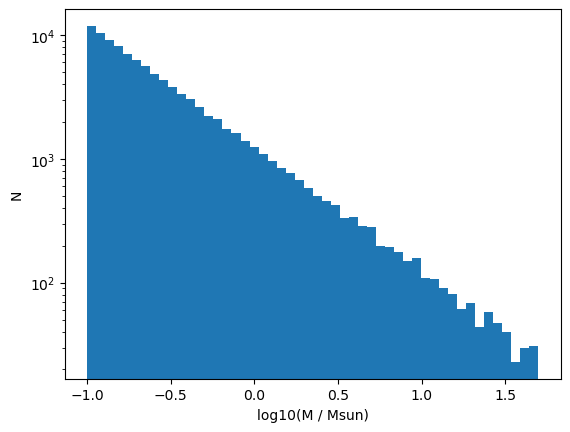

In [5]:
masses = sample_imf(alpha=2.0, m_min=0.1, m_max=50.0, size=100000)

# sanity check
import matplotlib.pyplot as plt
plt.hist(np.log10(masses), bins=50)
plt.xlabel("log10(M / Msun)")
plt.ylabel("N")
plt.yscale('log')
plt.show()

In [10]:
# ---------------------------
# Log-prior
# ---------------------------
def log_prior(theta):
    alpha = theta[0]
    if 1.01 < alpha < 5.0:
        return 0.0
    return -np.inf


# ---------------------------
# Log-likelihood
# ---------------------------
def log_likelihood(theta, masses, m_min, m_max):
    alpha = theta[0]

    if alpha <= 1.0:
        return -np.inf

    N = len(masses)

    norm = (m_min**(1.0-alpha) - m_max**(1.0-alpha))

    if norm <= 0:
        return -np.inf

    term1 = N * np.log(alpha - 1.0)
    term2 = -N * np.log(norm)
    term3 = -alpha * np.sum(np.log(masses))

    return term1 + term2 + term3


# ---------------------------
# Log-posterior
# ---------------------------
def log_probability(theta, masses, m_min, m_max):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, masses, m_min, m_max)

In [11]:
m_min = 0.1
m_max = 50.0

ndim = 1
nwalkers = 32

# initial guess near Salpeter
p0 = 2.0 + 1e-2 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim,
    log_probability,
    args=(masses, m_min, m_max)
)

sampler.run_mcmc(p0, 5000, progress=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:36<00:00, 51.80it/s]


State([[2.00254473]
 [1.99940139]
 [2.00182681]
 [2.00178388]
 [2.00168415]
 [2.00136757]
 [2.00918272]
 [2.00129037]
 [2.00880404]
 [2.00852874]
 [2.00121   ]
 [2.00141224]
 [2.00019676]
 [2.00442736]
 [2.00491475]
 [2.00450308]
 [2.0053655 ]
 [2.00704413]
 [2.00468183]
 [2.00748313]
 [2.00735229]
 [1.99896971]
 [2.00310684]
 [2.00526892]
 [2.00087696]
 [2.00498548]
 [1.99695049]
 [2.00544549]
 [1.99901535]
 [2.00582793]
 [2.00179106]
 [2.00578676]], log_prob=[33620.867569   33620.09505336 33620.77127559 33620.76401691
 33620.74649769 33620.68482471 33619.52246528 33620.66838439
 33619.70730066 33619.83349511 33620.65068908 33620.6940852
 33620.37655753 33620.89535913 33620.84962171 33620.88968017
 33620.78797518 33620.39509413 33620.8741924  33620.2499356
 33620.29503492 33619.91781619 33620.9099138  33620.80274908
 33620.57101975 33620.84117849 33618.85994878 33620.77509404
 33619.93736899 33620.7054274  33620.76524177 33620.71356936], blobs=None, random_state=('MT19937', array([171

In [12]:
burnin = 1000
samples = sampler.get_chain(discard=burnin, flat=True)

alpha_samples = samples[:,0]

print("alpha = {:.3f} +/- {:.3f}".format(
    np.mean(alpha_samples),
    np.std(alpha_samples)
))

alpha = 2.004 +/- 0.003


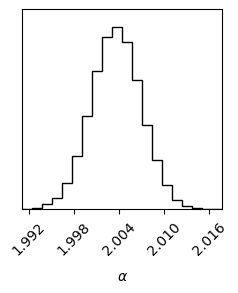

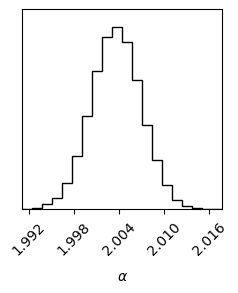

In [14]:
corner.corner(samples, labels=[r"$\alpha$"])

# Try out grid

In [16]:
def fit_alpha_mcmc(masses, m_min, m_max, nsteps=2000):

    ndim = 1
    nwalkers = 32

    p0 = 2.0 + 1e-2 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(
        nwalkers, ndim,
        log_probability,
        args=(masses, m_min, m_max)
    )

    sampler.run_mcmc(p0, nsteps, progress=False)

    samples = sampler.get_chain(discard=500, flat=True)
    alpha_med = np.median(samples[:,0])
    alpha_err = np.std(samples[:,0])

    return alpha_med, alpha_err

In [20]:
true_alphas = [1.8, 2.0, 2.2, 2.4, 2.6]

mass_ranges = [
    (0.1, 10),
    (0.1, 30),
    (0.1, 100),
    (0.5, 30),
    (1.0, 100)
]

Nstars_list = [200, 500, 1000, 5000, 20000]
rng = np.random.default_rng(42)

results = []

print("True_alpha  Mmin  Mmax   Nstars   Recovered_alpha ± sigma")
print("----------------------------------------------------------")

for Nstars in Nstars_list:
    for alpha_true in true_alphas:
        for m_min, m_max in mass_ranges:

            masses = sample_imf(alpha_true, m_min, m_max, Nstars, rng=rng)

            alpha_fit, alpha_err = fit_alpha_mcmc(masses, m_min, m_max)

            results.append([
                Nstars,
                alpha_true,
                m_min,
                m_max,
                alpha_fit,
                alpha_err
            ])

            print(f"{alpha_true:7.2f}  {m_min:4.1f}  {m_max:5.1f}  "
                  f"{Nstars:6d}   {alpha_fit:6.3f} ± {alpha_err:5.3f}")

True_alpha  Mmin  Mmax   Nstars   Recovered_alpha ± sigma
----------------------------------------------------------
   1.80   0.1   10.0     200    1.849 ± 0.073
   1.80   0.1   30.0     200    1.823 ± 0.066
   1.80   0.1  100.0     200    1.801 ± 0.061
   1.80   0.5   30.0     200    1.811 ± 0.077
   1.80   1.0  100.0     200    1.748 ± 0.069
   2.00   0.1   10.0     200    1.936 ± 0.077
   2.00   0.1   30.0     200    2.031 ± 0.078
   2.00   0.1  100.0     200    1.943 ± 0.069
   2.00   0.5   30.0     200    1.920 ± 0.080
   2.00   1.0  100.0     200    1.968 ± 0.079
   2.20   0.1   10.0     200    2.262 ± 0.095
   2.20   0.1   30.0     200    2.251 ± 0.089
   2.20   0.1  100.0     200    2.189 ± 0.085
   2.20   0.5   30.0     200    2.115 ± 0.089
   2.20   1.0  100.0     200    2.261 ± 0.095
   2.40   0.1   10.0     200    2.401 ± 0.102
   2.40   0.1   30.0     200    2.538 ± 0.110
   2.40   0.1  100.0     200    2.272 ± 0.092
   2.40   0.5   30.0     200    2.446 ± 0.108
   2.40  

In [21]:
results = np.array(results)

In [22]:
np.savetxt(
    "imf_mcmc_results.csv",
    results,
    delimiter=",",
    header="Nstars,alpha_true,Mmin,Mmax,alpha_fit,alpha_err",
    comments=""
)

In [31]:
# Path to your ASCII file
filename = "weisz_2013_tab1.txt"

colnames = [
    "row",
    "cluster",
    "logN",
    "logMratio",
    "alpha",
    "sigma",
    "min_mass",
    "max_mass",
    "delta_alpha_ratio"
]

df = pd.read_csv(
    filename,
    sep=r"\s+",
    skiprows=5,
    engine="python",
    usecols=range(9)   # <-- ignore reference column
)

df.columns = colnames

# Drop any footer / non-numeric rows safely
df = df[pd.to_numeric(df["logN"], errors="coerce").notnull()]

# Keep only what you want
df_imf = df[["cluster", "logN", "alpha", "sigma", "min_mass", "max_mass"]]
df_imf["N_stars"] = 10**df_imf["logN"]

df_imf = df_imf[["cluster", "N_stars", "alpha", "sigma", "min_mass", "max_mass"]]

print(df_imf.head())
print(df_imf.tail())

ParserError: Defining usecols with out-of-bounds indices is not allowed. [3, 4, 5, 6, 7, 8] are out-of-bounds.